In [3]:
import math
import random
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Практические задания

#### 1. Реализуйте функцию norm(v, p) — Lp-норма вектора (без np.linalg). Проверьте на p=1, 2, ∞.

In [4]:
# Создаем вектор
x = [3.0, -1.5, 2.7, 0.0, 5.1]

# Создаем функцию
def norm(v, p):
    if not v:  # Проверяем, что вектор не пустой (иначе норма 0)
        return 0.0
    if p == float('inf'):  # Проверяем вектор на бесконечность (возращаем максимальный модуль из вектора)
        return max(abs(i) for i in v)
    else:
        sum_p = 0  # Инициализируем счетчик
        for i in v:  # Проходим по каждому элементу вектора
            sum_p += abs(i) ** p  # Возводим каждый элемент в квадрат
        return sum_p ** (1 / p)  # Возращаем корень суммы квадратов

# Вызов функции        
print(norm(x, 1))  # L1 норма — сумма модулей
print(norm(x, 2))  # L2 норма — длина модулей (евклидова)
print(norm(x, float('inf')))  # L∞-норма - максимум модуля

12.3
6.674578638386096
5.1


#### 2. Косинус без np. Реализуйте косинусное расстояние, используя только math.sqrt и циклы. Сравните с NumPy-версией на 10 случайных парах.

In [5]:
# Создаем вспомогательную функцию скалярного произведения
def dot(a, b):
    if len(a) != len(b):  # Определяем равность векторов
        raise ValueError('Ошибка: Векторы должны иметь одинаковую длину')
    result = 0  # Инициализируем счетчик
    for x, y in zip(a, b):  # Проходим по обоим векторам одновременно
        result += x * y  # Умножаем пару и добавляем в счетчик
    return result  # Возвращаем результат
    
# Создаем вспомогательную функцию для нахождения длины векторов (L2-норма)
def l2_norm(v):
    sum_sq = 0  # Инициализируем счетчик
    for x in v:
        sum_sq += x * x  # Возводим в квадрат и добавляем в счетчик
    return math.sqrt(sum_sq)  # Возвращаем квадратный корень из счетчика
    
# Создаем основную функцию для вычисления расстояния косинуса
def cosine_distance(a, b, verbose=False):
    num = dot(a, b)  # Считаем скалярное произведение
    len_a = l2_norm(a)  #Считаем длину вектора a
    len_b = l2_norm(b)  #Считаем длину вектора b
    den = l2_norm(a) * l2_norm(b)  # Вычисляем знаменатель
    if verbose:  # Отладка (нужно verbose включить True)
        print(f'[DEBAG] dot={num}, |a|={len_a}, |b|={len_b}')
    if den < 1e-12:  # Защита от деления на ноль (1e-12 очень маленькое число)
        return 1.0 # Если вектор нулевой, считаем, что расстояние максимальное (1.0)
    sim = num / den # Считаем косинус (похожесть)
    
    return 1.0 - sim  # Считаем расстояние. Если похожесть 1 (векторы одинаковые), расстояние будет 0.

In [6]:
# Делаем сравнение с NumPy-версией на 10 случайных парах
print("Начинаем тестирование на 10 случайных векторах...")
print("-" * 50)

# Цикл повторяет действие 10 раз
for i in range(10):
    # Создаём два случайных вектора длиной 5
    a = [random.uniform(-5, 5) for _ in range(5)]
    b = [random.uniform(-5, 5) for _ in range(5)]
    my_result = cosine_distance(a, b)  # Вызываем функцию косинуса (в которой находили расстояние)
    # Превращаем списки в массивы numpy
    a_np = np.array(a)
    b_np = np.array(b)
    # dot(a,b) / (norm(a)*norm(b)) — по аналогии раннее. Мы вычитаем из 1.
    np_sim = np.dot(a_np, b_np) / (np.linalg.norm(a_np) * np.linalg.norm(b_np))
    np_result = 1.0 - np_sim

    # Проверяем, насколько наши результаты близки.
    # math.isclose возвращает True, если числа почти равны
    is_match = math.isclose(my_result, np_result, rel_tol=1e-5)
    status = 'Совпало' if is_match else 'РАЗЛИЧАЕТСЯ'
    print(f"Тест {i+1}: Мой ответ: {my_result:.4f} | NumPy: {np_result:.4f} | {status}")  # Вывод результатов

Начинаем тестирование на 10 случайных векторах...
--------------------------------------------------
Тест 1: Мой ответ: 0.7925 | NumPy: 0.7925 | Совпало
Тест 2: Мой ответ: 0.5302 | NumPy: 0.5302 | Совпало
Тест 3: Мой ответ: 1.3884 | NumPy: 1.3884 | Совпало
Тест 4: Мой ответ: 0.9097 | NumPy: 0.9097 | Совпало
Тест 5: Мой ответ: 0.7589 | NumPy: 0.7589 | Совпало
Тест 6: Мой ответ: 0.4735 | NumPy: 0.4735 | Совпало
Тест 7: Мой ответ: 0.6085 | NumPy: 0.6085 | Совпало
Тест 8: Мой ответ: 1.4954 | NumPy: 1.4954 | Совпало
Тест 9: Мой ответ: 0.1709 | NumPy: 0.1709 | Совпало
Тест 10: Мой ответ: 0.7793 | NumPy: 0.7793 | Совпало


#### 3. Топ-5 похожих слов. Загрузите готовые word-эмбеддинги (например, GloVe 50d). Для слова king найдите 5 ближайших по косинусу.

In [7]:
# Определяем путь к файлу источника
notebook_folder = Path().resolve()
project_root = notebook_folder.parent.parent
file_path = project_root / 'data' / 'glove.6B.50d.txt'

# Построчное чтение файла
embeddings = {}  # Создаем пустой словарь
with open(file_path, 'r', encoding='utf-8') as f:  # Открываем файл
    for line in f:
        values = line.strip().split()  # Разделяем строку на слово
        word = values[0]  # Cохранение слов и их 50-мерных векторов в словарь
        vector = np.array([float(num) for num in values[1:]], dtype='float32')  # Преобразовываем числа в список float
        embeddings[word] = vector  

# Проверка наличия целевого слова
if 'king' not in embeddings:  # Подготовка поиска для king
    print("Ошибка: слово 'king' не найдено в эмбеддингах")  # Защита от KeyError: проверяем наличие слова в загруженных данных
else:
    vector_king = embeddings['king']
    candidates = []  # Создаем пустой список

    # Вычисление сходства со всеми словами
    for word in embeddings:
        if word == 'king':  # Если слово равно king то пропускаем
            continue
        vector_word = embeddings[word]
    
    # Расчёт косинусного сходства с каждым словом, исключая само целевое
    dot_product = np.dot(vector_king, vector_word)  # Вычисляем скалярное произведение векторов
    # Нормы (длины) векторов
    norm_king = np.linalg.norm(vector_king)
    norm_word = np.linalg.norm(vector_word)
    # Находим косинусное сходство
    sim = dot_product / (norm_king * norm_word)
    candidates.append((word, sim))  # Добавляем ключ-сходство в список

# Сортировка по убыванию и выборка топ-5 результатов
candidates.sort(key=lambda x: x[1], reverse=True)
top_5 = candidates[:5]
print('5 ближайших слов к "king" по косинусному сходству:')
for word, sim in top_5:
    print(f'{word}: {sim:.4f}')

5 ближайших слов к "king" по косинусному сходству:
sandberger: -0.2464


#### 4. Король − мужчина + женщина = ? Проверьте классическое равенство на эмбеддингах. Должно выйти что-то близкое к queen.

In [8]:
# Извлекаем базовые векторы
v_king = embeddings['king']
v_man = embeddings['man']
v_woman = embeddings['woman']

# Вычисляем целевой вектор
target_vector = []  # Создаем пустой список
for i in range(len(v_king)):
    target_vector.append(v_king[i] - v_man[i] + v_woman[i])  # Поэлементно вычисляем вектор

# Ищем ближайшее слово к target_vector
results = []  # Создаем пустой список
for word in embeddings:
    if word in ['king', 'man', 'woman']:
        continue  # Исключаем исходные слова 'king', 'man', 'woman'
    sim = np.dot(target_vector, embeddings[word])  # Находим косинусное сходство
    results.append((word, sim))  # Добавляем результаты в список

# Сортировка по убыванию и выборка топ-3 результатов
results.sort(key=lambda x: x[1], reverse=True)
top_3 = results[:3]
print('Поиск ближайшего семантического аналога в словаре')
for word, sim in top_3:
    print(f'{word}: {sim:.4f}')

Поиск ближайшего семантического аналога в словаре
emperor: 25.0902
queen: 24.6411
daughter: 24.2824


#### 5. Нормализация. Напишите функцию normalize(v), возвращающую единичный вектор того же направления. Что произойдёт, если подать нулевой вектор?

In [9]:
# Создаем функцию для нахождения длины вектора (L2-норма)
def normalize(v):
    # Вычисляем L2-норму. Если вектор нулевой, нормализация не имеет смысла (деление на ноль)
    norm = np.linalg.norm(v)
    if norm < 1e-12:
        raise ValueError('Ошибка: длинна вектора не должна равняться нулю')
    else:
        result = []  # Инициализируем список
        for x in v:
            result.append(x / norm)  # Делим каждую координату на длину, чтобы получить единичный вектор
    return result
# Выводим результат (убеждаемся, что все сделано правильно)
v = np.array([0, 3, 4])
print('Исходный вектор:', v)
print('Длина вектора:', np.linalg.norm(v))  # 5.0
print('Нормализованный вектор:', normalize(v))  # [0.0 0.6 0.8]
print('Длина нормализованного:', np.linalg.norm(normalize(v)))  # 1.0

Исходный вектор: [0 3 4]
Длина вектора: 5.0
Нормализованный вектор: [np.float64(0.0), np.float64(0.6), np.float64(0.8)]
Длина нормализованного: 1.0


Ответ на вопрос: Что произойдёт, если подать нулевой вектор?
`С математической точки зрения, у нулевого вектора нет направления, поэтому нормализовать его невозможно. С точки зрения кода — произойдёт деление на ноль. Мы должны перехватить эту ситуацию заранее с помощью условия if и явно сообщить пользователю об ошибке.`

#### 6. Проекция. Реализуйте проекцию вектора a на b: $$\text{proj}_b \mathbf{a} = \frac{\mathbf{a} \cdot \mathbf{b}}{\mathbf{b} \cdot \mathbf{b}} \mathbf{b}$$Визуализируйте на 2D через matplotlib.

In [10]:
# Создаем функцию для вычисления знаменателя и проверка на ноль
def projection(a, b):
    num_1 = dot(a, b)  # Вычислиям скалярное произведение a·b
    num_2 = dot(b, b)  # Вычислиям скалярное произведение b·b
    # Проверяем, что вектор b не нулевой (иначе деление на ноль)
    if num_2 == 0:
        raise ValueError('Ошибка: длинна вектора b не должна равняться нулю')
    # Вычисляем коэффициент проекции    
    scalar = num_1 / num_2
    # Создаем вектор proj
    proj = []
    for x in b:
        proj.append(scalar * x)  # Умножаем каждый элемент в b на скаляр для получения вектора проекции
    return proj

# Делаем проверку (выводим результаты)
a = np.array([3, 4])
b = np.array([5, 0])
result = projection(a, b)
print(f"Результат проекции: ({result[0]:.1f}, {result[1]:.1f})")  # [3, 0]

Результат проекции: (3.0, 0.0)


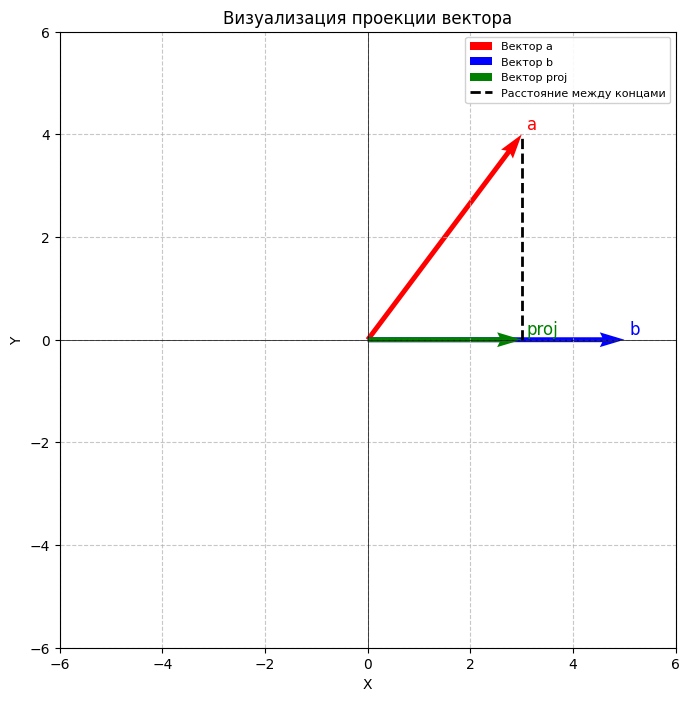

In [15]:
def visualize_projection(a, b, proj):
    fig, ax = plt.subplots(figsize=(8, 8))  # Создаем фигуру и оси
    ax.set_aspect('equal')  # Устанвливаем равные масштабы по осям
    ax.grid(True, linestyle='--', alpha=0.7)  # Добавляем сетку для наглядности
    
    # Подписи осей
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Визуализация проекции вектора')

    # Определяем границы графика с запасом
    all_vectors = np.array([a, b, proj])
    max_val = np.abs(all_vectors).max() * 1.2
    ax.set_xlim(- max_val, max_val)
    ax.set_ylim(- max_val, max_val)

    # Добавляем оси X и Y через начало координат
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Рисуем вектор a (стрелка от начала координат)
    ax.quiver(0, 0, a[0], a[1],
                 angles='xy', scale_units='xy', scale=1,
                 color='red', label='Вектор a', width=0.008)

    # Рисуем вектор b (стрелка от начала координат)
    ax.quiver(0, 0, b[0], b[1],
                 angles='xy', scale_units='xy', scale=1,
                 color='blue', label='Вектор b', width=0.008)

    # Рисуем вектор proj (стрелка от начала координат)
    ax.quiver(0, 0, proj[0], proj[1],
                 angles='xy', scale_units='xy', scale=1,
                 color='green', label='Вектор proj', width=0.008)

    # Рисуем пунктирную линию от конца proj до конца a
    ax.plot([proj[0], a[0]], [proj[1], a[1]],
               'k--', linewidth=2, label='Расстояние между концами')

    # Добавляем подписи векторов
    ax.text(a[0] + 0.1, a[1] + 0.1, 'a', fontsize=12, color='red')
    ax.text(b[0] + 0.1, b[1] + 0.1, 'b', fontsize=12, color='blue')
    ax.text(proj[0] + 0.1, proj[1] + 0.1, 'proj', fontsize=12, color='green')
    
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9)  # Добавляем легенду
    plt.show()  # Показываем график

if __name__ == '__main__':
    # Задаём тестовые векторы
    a = np.array([3, 4])
    b = np.array([5, 0])
    # Вычисляем проекцию (пример)
    scalar = np.dot(a, b) / np.dot(b, b)
    proj = scalar * b
    
    # Визуализируем
    visualize_projection(a, b, proj)

#### 7. Угол между документами. Возьмите 5 коротких текстов. Постройте bag-of-words векторы. Посчитайте попарные косинусные близости. Какие документы оказались похожими?

#### 8. Перпендикулярность. Сгенерируйте случайный вектор в R^100. Найдите хотя бы один ненулевой вектор, перпендикулярный ему (скалярное произведение = 0).